# let's histogram

Histograma das durações de cada percept com regressão gamma


In [72]:
import os
import glob
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


In [73]:
tsv_folder = "../data/keypress-events-tsv"

# get list of tsv files inside this folder
tsv_files = glob.glob(os.path.join(tsv_folder, "*task-UA*_events.tsv"))

print(f"Found {len(tsv_files)} tsv files in {tsv_folder}")

Found 60 tsv files in ../data/keypress-events-tsv


In [74]:
# let's iterate over all the tsv files and retrieve the durations of the 'coherent' and 'incoherent' conditions

# Initialize an empty list to hold all durations and their types
all_durations = []

for tsv_file in tsv_files:
    df = pd.read_csv(tsv_file, sep="\t")

    for trial_type in ["coherent", "incoherent"]:
        durations = df.loc[df["trial_type"] == trial_type, "duration"].values
        all_durations.extend((d, trial_type) for d in durations)

        # throw warning if any of the durations is 120 with filename
        if any(d > 60 for d in durations):
            print(f"Warning: Found durations greater than 60 in {tsv_file} for trial type {trial_type}")

# Create the final DataFrame
df = pd.DataFrame(all_durations, columns=["duration", "trial_type"])
df

,duration,trial_type
0,2.5,coherent
1,5.0,coherent
2,2.5,coherent
3,7.5,coherent
4,2.5,coherent
...,...,...
2227,2.5,incoherent
2228,7.5,incoherent
2229,2.5,incoherent
2230,12.5,incoherent


In [75]:
# clean
df = df[(df["duration"] <= 60)]

In [76]:
# summarize df
df_summary = df.groupby("trial_type")["duration"].describe()
df_summary

,count,mean,std,min,25%,50%,75%,max
trial_type,,,,,,,,
coherent,1146.0,7.314136,7.37070,0.5,2.5,5.0,9.0,60.0
incoherent,1078.0,4.855751,4.08205,0.5,2.5,4.0,6.0,58.0


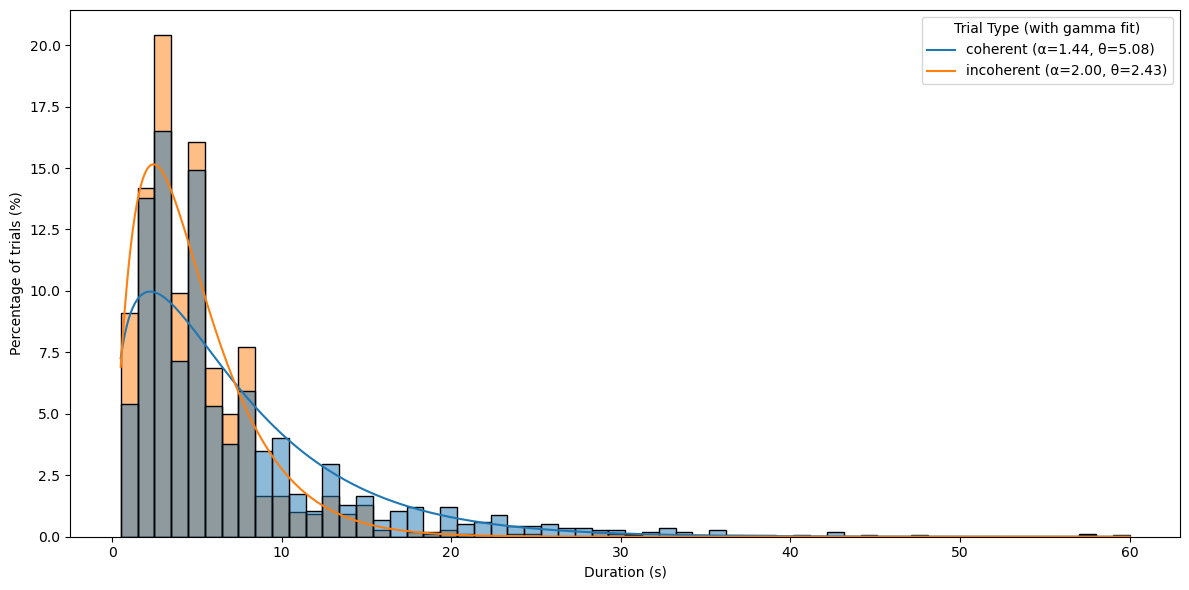

In [77]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import gamma

plt.figure(figsize=(12, 6))

# Plot the histogram
hist = sns.histplot(
    data=df,
    x="duration",
    hue="trial_type",
    bins=60,
    kde=False,
    stat="percent",
    common_norm=False,
    alpha=0.5,
    legend=True,
)

# Get consistent binning info
bin_edges = hist.patches[0].get_path().vertices[:, 0]
bin_edges = np.unique(bin_edges)
bin_width = bin_edges[1] - bin_edges[0]
x_plot = np.linspace(df["duration"].min(), df["duration"].max(), 500)

# Fit gamma and overlay PDF for each group
for trial_type, group_data in df.groupby("trial_type"):
    y = group_data["duration"]

    # Fit gamma distribution
    shape, loc, scale = gamma.fit(y, floc=0)  # fixing loc=0, optional

    # PDF and scale it to percent
    pdf = gamma.pdf(x_plot, shape, loc=loc, scale=scale)
    pdf_scaled = pdf * bin_width * 100

    # Plot
    plt.plot(x_plot, pdf_scaled, label=f"{trial_type} (α={shape:.2f}, θ={scale:.2f})")

plt.xlabel("Duration (s)")
plt.ylabel("Percentage of trials (%)")
plt.legend(title="Trial Type (with gamma fit)")
plt.tight_layout()
plt.show()